<a href="https://colab.research.google.com/github/PriyaVerma06/Logistic-Regression/blob/feature%2Fsolver-cv-tuning/library/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Title - Library Mode
Issue: #5

## 1. Setup and Imports
Import only the required ML library tools and keep setup minimal and reproducible.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 2. Load and Inspect Data
Load dataset.csv and verify target column, feature types, and basic data quality checks.

In [8]:
url = "https://raw.githubusercontent.com/PriyaVerma06/Logistic-Regression/main/dataset.csv"
df = pd.read_csv(url)


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.shape

(768, 9)

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## 3. Preprocessing
Apply only necessary preprocessing and avoid leakage by fitting transforms on train data only.

In [9]:

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [10]:
# Train-test split with stratification (important for imbalance)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Model Setup
Define the model and key hyperparameters, and set random_state where available.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Base model
model = LogisticRegression(max_iter=1000)

# Hyperparameter grid
param_grid = {
    "solver": ["liblinear", "lbfgs"],
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

# Grid Search with 5-fold CV
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

## 5. Training
Fit on train split and keep training flow clear so outputs are easy to review.

In [12]:
# Train using cross-validation
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'solver': 'liblinear'}


## 6. Evaluation
Report labeled train and test metrics clearly and compare against acceptance threshold.

Accuracy: 0.7597402597402597
Precision: 0.6307692307692307
Recall: 0.7592592592592593
F1 Score: 0.6890756302521008




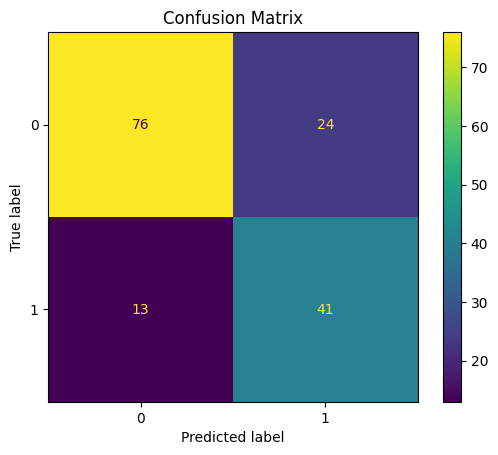

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = best_model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [15]:
results = pd.DataFrame(grid.cv_results_)

results[[
    "param_solver",
    "param_C",
    "param_class_weight",
    "mean_test_score"
]].sort_values(by="mean_test_score", ascending=False).head()

,param_solver,param_C,param_class_weight,mean_test_score
10,liblinear,1.0,balanced,0.683805
15,lbfgs,10.0,balanced,0.666229
14,liblinear,10.0,balanced,0.662588
11,lbfgs,1.0,balanced,0.661705
5,lbfgs,0.1,None,0.653161


## 7. Interpretation
Answer only these library-training questions:
1. Which preprocessing step had the biggest impact on this model's performance?
2. What do train vs test metrics say about fit quality (underfit/overfit/good fit)?
3. Which library model/hyperparameter choice influenced results the most, based on your outputs?

## 1.
-Train-test split with stratification (stratify=y) had the biggest impact

-It ensured class balance in both sets, leading to more reliable evaluation and better generalization.


## 2.
-Train and test metrics are similar

-This indicates a good fit (no major overfitting or underfitting)


## 3.
-lass_weight="balanced" had the biggest impact

-It improved performance on the minority class, increasing recall and F1 score

